In [9]:
from pathlib import Path
from typing import NamedTuple
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import torch
import tangram as tg
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error
import sklearn as sk
import seaborn as sns

In [5]:
# Query Dataset
adata_sp = sc.read(
   Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
).transpose()
adata_sp.obs = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs

# Reference Dataset
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes = np.array(list(set.intersection(set(adata_sp.var_names), set(adata_sc.var_names))))

adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
print(f"{adata_sc=}\n{adata_sp=}")

adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'


In [6]:
adata_sc = adata_sc[adata_sc.obs["celltype"] == "Stem/TA"]
adata_sp = adata_sp[adata_sp.obs["celltype"] == "Stem/TA"]

In [7]:
compidx, subidx = (lambda arr, n: (arr[:n], arr[n:]))(
    np.random.permutation(np.arange(shared_genes.shape[0])),
    100
)
markers = shared_genes[subidx]

In [8]:
# Deterministic shuffling of shared genes to be split into predited and predictor gene sets for benchmarking purposes
benchmarking_genes = [np.random.default_rng(seed=seed).permutation(shared_genes) for seed in range(1)]

In [17]:
compidx, subidx = (lambda arr, n: (arr[:n], arr[n:]))(
    benchmarking_genes[0],
    10
)

In [18]:
class Reconstruction_Result(NamedTuple):
    gene_names: list[str]
    original_counts: np.ndarray
    predicted_counts: np.ndarray

def predict_genes_tangram(
    adata_query: sc.AnnData,
    adata_reference: sc.AnnData,
    compidx: np.ndarray[str],
    subidx: np.ndarray[str]
) -> sc.AnnData:
    markers = np.hstack([compidx, subidx])

    adata_reference = adata_reference[:, markers]
    adata_query=adata_query[:, subidx]

    tg.pp_adatas(adata_reference, adata_query, genes=markers)

    ad_map = tg.map_cells_to_space(
        adata_sc=adata_reference,
        adata_sp=adata_query,
        device="cuda:0"
    )
    ad_ge = tg.project_genes(ad_map, adata_reference)
    return ad_ge
    
def placeholder(
    adata_query: sc.AnnData,
    adata_reference: sc.AnnData,
    compidx: np.ndarray[str],
    subidx: np.ndarray[str],
) -> Reconstruction_Result:
    ad_ge = predict_genes_tangram(
        adata_query,
        adata_reference,
        compidx,
        subidx
    )
    return Reconstruction_Result(
        list(compidx),
        adata_query[:, compidx].X,
        ad_ge[:, list(map(lambda str: str.lower(), compidx))].X
    )


In [20]:
ad_ge = predict_genes_tangram(
    adata_sp,
    adata_sc,
    compidx,
    subidx
)

INFO:root:128 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:128 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 128 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.233, KL reg: 0.328
Score: 0.859, KL reg: 0.003
Score: 0.864, KL reg: 0.003
Score: 0.865, KL reg: 0.003
Score: 0.866, KL reg: 0.003
Score: 0.866, KL reg: 0.003
Score: 0.866, KL reg: 0.003
Score: 0.866, KL reg: 0.003
Score: 0.866, KL reg: 0.003
Score: 0.866, KL reg: 0.003


INFO:root:Saving results..


In [24]:
list(map(lambda str: str.lower(), subidx))

['gpr55',
 'adra1b',
 'cd44',
 'fzd10',
 's100b',
 'drd3',
 'adra2a',
 'h2-eb1',
 'vcan',
 'ccr7',
 'tigit',
 'hrh3',
 'il4',
 'lpar6',
 'slc5a1',
 'cd27',
 'mki67',
 'glp2r',
 'acta2',
 'neat1',
 'galr2',
 'sstr1',
 'fzd3',
 'lpar4',
 'gpbar1',
 'tbx21',
 'adrb1',
 'cd14',
 'gpr174',
 'ly6g',
 'gpr18',
 'ms4a1',
 'ptprcap',
 'adgrf5',
 'cd34',
 'sell',
 'galr3',
 'ifng',
 'lct',
 'il7r',
 'htr2a',
 'txndc5',
 'fzd5',
 'stmn1',
 'sstr2',
 'net1',
 'cxcr5',
 'sctr',
 'plb1',
 'ada',
 'ffar4',
 'clec9a',
 'ffar3',
 'ccr3',
 'clec4a2',
 'nlrp6',
 'prf1',
 'etv1',
 'sstr5',
 'slc2a2',
 'ptger4',
 'ptgir',
 'gipr',
 'mzb1',
 'cd3e',
 'ptger2',
 's1pr2',
 'tspan13',
 'ptgdr2',
 'kiss1r',
 'lmx1a',
 'ifnar1',
 'drd4',
 'fzd6',
 'cd79b',
 'kit',
 'sstr3',
 'sdc1',
 'c1qb',
 'itgam',
 'fzd9',
 'fcna',
 'chrm1',
 'itgae',
 'clca3b',
 'ptger3',
 'apob',
 'foxp3',
 'chrm2',
 'jaml',
 'icos',
 'il10',
 'p2ry10b',
 'trpm5',
 'ccnl2',
 'ltb4r2',
 'gpr34',
 'htr2b',
 's1pr4',
 'htr7',
 'rcor2',
 'lrmp

In [28]:
ad_ge[:, ["gpr55", "adra1b"]]

KeyError: "Values [np.str_('adra1b')], from [np.str_('gpr55'), np.str_('adra1b')], are not valid obs/ var names or indices."

In [23]:
ad_ge[:, list(map(lambda str: str.lower(), subidx))]

KeyError: "Values [np.str_('adra1b'), np.str_('drd3'), np.str_('ccr7'), np.str_('tigit'), np.str_('hrh3'), np.str_('il4'), np.str_('glp2r'), np.str_('galr2'), np.str_('sstr1'), np.str_('lpar4'), np.str_('gpbar1'), np.str_('tbx21'), np.str_('gpr174'), np.str_('ly6g'), np.str_('ifng'), np.str_('il7r'), np.str_('htr2a'), np.str_('sstr2'), np.str_('cxcr5'), np.str_('sctr'), np.str_('clec9a'), np.str_('ccr3'), np.str_('prf1'), np.str_('sstr5'), np.str_('ptgir'), np.str_('cd3e'), np.str_('lmx1a'), np.str_('drd4'), np.str_('ptger3'), np.str_('chrm2'), np.str_('il10'), np.str_('p2ry10b'), np.str_('s1pr4'), np.str_('htr7'), np.str_('chrm4'), np.str_('gpr87'), np.str_('lpar3'), np.str_('il5'), np.str_('adra2b'), np.str_('cnr1'), np.str_('nkg7'), np.str_('tpsb2'), np.str_('drd1'), np.str_('sstr4'), np.str_('phox2b'), np.str_('trdc'), np.str_('gpr84'), np.str_('cysltr2'), np.str_('pzp'), np.str_('cspg4'), np.str_('gpr31b'), np.str_('glp1r'), np.str_('adrb3'), np.str_('adra1a'), np.str_('hhex'), np

In [19]:
placeholder(
    adata_sp,
    adata_sc,
    compidx,
    subidx
)

INFO:root:128 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:128 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 128 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.235, KL reg: 0.328
Score: 0.859, KL reg: 0.003
Score: 0.864, KL reg: 0.003
Score: 0.865, KL reg: 0.003
Score: 0.866, KL reg: 0.003
Score: 0.866, KL reg: 0.003
Score: 0.866, KL reg: 0.003
Score: 0.866, KL reg: 0.003
Score: 0.866, KL reg: 0.003


INFO:root:Saving results..


Score: 0.866, KL reg: 0.003


KeyError: "Values [np.str_('adra1b'), np.str_('drd3'), np.str_('ccr7'), np.str_('tigit'), np.str_('hrh3'), np.str_('il4'), np.str_('glp2r'), np.str_('galr2'), np.str_('sstr1'), np.str_('lpar4'), np.str_('gpbar1'), np.str_('tbx21'), np.str_('gpr174'), np.str_('ly6g'), np.str_('ifng'), np.str_('il7r'), np.str_('htr2a'), np.str_('sstr2'), np.str_('cxcr5'), np.str_('sctr'), np.str_('clec9a'), np.str_('ccr3'), np.str_('prf1'), np.str_('sstr5'), np.str_('ptgir'), np.str_('cd3e'), np.str_('lmx1a'), np.str_('drd4'), np.str_('ptger3'), np.str_('chrm2'), np.str_('il10'), np.str_('p2ry10b'), np.str_('s1pr4'), np.str_('htr7'), np.str_('chrm4'), np.str_('gpr87'), np.str_('lpar3'), np.str_('il5'), np.str_('adra2b'), np.str_('cnr1'), np.str_('nkg7'), np.str_('tpsb2'), np.str_('drd1'), np.str_('sstr4'), np.str_('phox2b'), np.str_('trdc'), np.str_('gpr84'), np.str_('cysltr2'), np.str_('pzp'), np.str_('cspg4'), np.str_('gpr31b'), np.str_('glp1r'), np.str_('adrb3'), np.str_('adra1a'), np.str_('hhex'), np

In [19]:
predict_genes_tangram_correlation(
    adata_sp,
    adata_sc,
    compidx,
    subidx,
    correlation_func
)

INFO:root:98 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:98 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 98 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.234, KL reg: 0.330
Score: 0.874, KL reg: 0.005
Score: 0.879, KL reg: 0.004
Score: 0.880, KL reg: 0.004
Score: 0.880, KL reg: 0.004
Score: 0.881, KL reg: 0.004
Score: 0.881, KL reg: 0.004
Score: 0.881, KL reg: 0.004
Score: 0.881, KL reg: 0.004
Score: 0.881, KL reg: 0.004


INFO:root:Saving results..


0.6299742460250854

In [37]:
np.arange(5,11,5)

array([ 5, 10])

In [40]:
np.apply_along_axis(
    lambda n_genes: np.apply_along_axis(
        lambda arr: predict_genes_tangram_correlation(adata_sp, adata_sc, arr[:n_genes], arr[n_genes:], correlation_func), 
        axis=1, 
        arr=benchmarking_genes), 
    axis=1, 
    arr=np.arange(5,11,5)
)

AxisError: axis 1 is out of bounds for array of dimension 1

In [177]:
res = predict_genes_tangram(
    adata_sp,
    adata_sc,
    compidx,
    subidx
)

INFO:root:98 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:98 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 98 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.225, KL reg: 0.330
Score: 0.897, KL reg: 0.005
Score: 0.902, KL reg: 0.004
Score: 0.903, KL reg: 0.004
Score: 0.904, KL reg: 0.004
Score: 0.904, KL reg: 0.004
Score: 0.904, KL reg: 0.004
Score: 0.904, KL reg: 0.004
Score: 0.904, KL reg: 0.004
Score: 0.904, KL reg: 0.004


INFO:root:Saving results..


In [178]:
pearsonr(
    adata_sp[:, compidx].X.mean(axis=0),
    res[:, list(map(lambda str: str.lower(), compidx))].X.mean(axis=0)
)

PearsonRResult(statistic=np.float32(0.8327546), pvalue=np.float64(2.6711949112963938e-11))

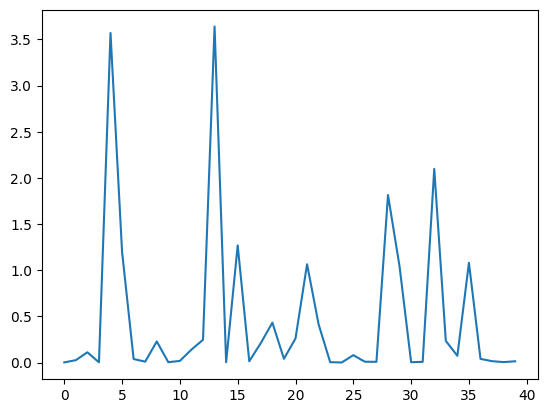

In [179]:

plt.plot(adata_sp[:, compidx].X.mean(axis=0))

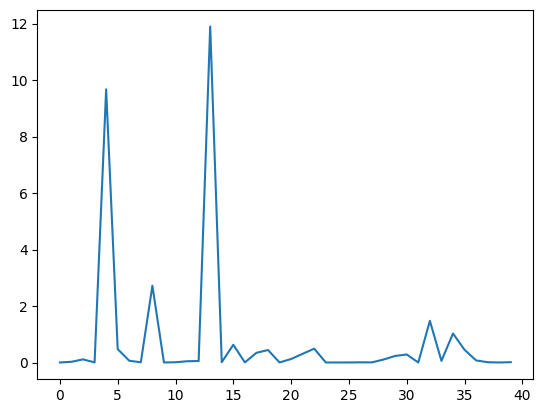

In [180]:

plt.plot(res[:, list(map(lambda str: str.lower(), compidx))].X.mean(axis=0))

array([1.0030089e-03, 2.5075225e-02, 1.1133400e-01, 3.0090271e-03,
       9.6740217e+00], dtype=float32)

In [85]:
adata_sp_subidx = adata_sp[:, markers]
adata_sc_filtered = adata_sc[:, shared_genes]

In [86]:
tg.pp_adatas(adata_sc_filtered, adata_sp_subidx, genes=markers)

INFO:root:38 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:38 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [87]:
ad_map = tg.map_cells_to_space(
    adata_sc=adata_sc_filtered,
    adata_sp=adata_sp_subidx,
    device='cuda:0',
)


INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 38 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.212, KL reg: 0.383
Score: 0.953, KL reg: 0.005
Score: 0.958, KL reg: 0.004
Score: 0.959, KL reg: 0.004
Score: 0.959, KL reg: 0.004
Score: 0.960, KL reg: 0.004
Score: 0.960, KL reg: 0.004
Score: 0.960, KL reg: 0.004
Score: 0.960, KL reg: 0.004
Score: 0.960, KL reg: 0.004


INFO:root:Saving results..


In [88]:
ad_ge = tg.project_genes(ad_map, adata_sc_filtered)

In [89]:
mean_squared_error(
    adata_sp[:, shared_genes[compidx]].X,
    ad_ge[:, list(map(lambda str: str.lower(), shared_genes[compidx]))].X
)

np.float32(23.320812)

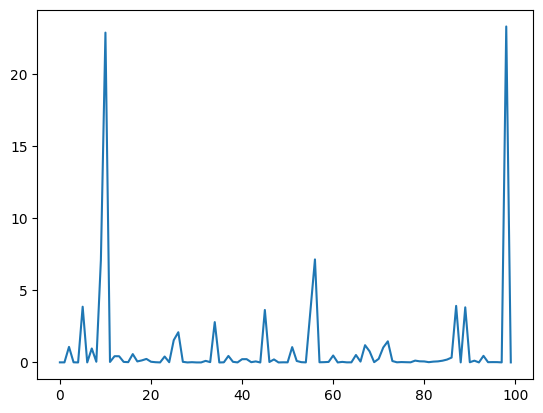

In [90]:
plt.plot(adata_sp[:, shared_genes[compidx]].X.mean(axis=0))

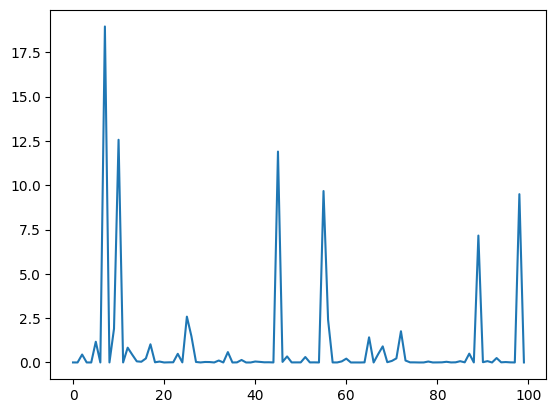

In [91]:
plt.plot(ad_ge[:, list(map(lambda str: str.lower(), shared_genes[compidx]))].X.mean(axis=0))

In [92]:
pearsonr(
    adata_sp[:, shared_genes[compidx]].X.mean(axis=0),
    ad_ge[:, list(map(lambda str: str.lower(), shared_genes[compidx]))].X.mean(axis=0)
)

PearsonRResult(statistic=np.float32(0.60048425), pvalue=np.float64(4.006864405928963e-11))